In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [2]:
print("1. Memuat dan Membersihkan Data...")

dataset_path = 'dataset.csv'
df = pd.read_csv(dataset_path)

df['Harga'] = df['Harga'].str.replace('Rp', '', regex=False).str.replace(',', '', regex=False)
df['Harga'] = df['Harga'].str.strip().replace('-', np.nan)
df['Harga'] = df['Harga'].replace('', np.nan)

df_clean = df.dropna()

df_clean['Harga'] = df_clean['Harga'].astype(int)

X = df_clean.drop(columns=[df_clean.columns[-1]]) 
y = df_clean[df_clean.columns[-1]]

X = pd.get_dummies(X, drop_first=True)
print(f"Total data bersih: {X.shape[0]} baris, {X.shape[1]} fitur.")

1. Memuat dan Membersihkan Data...
Total data bersih: 36068 baris, 120 fitur.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_41968\3653390061.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Harga'] = df_clean['Harga'].astype(int)


In [3]:
y_log = np.log1p(y)

In [4]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Lakukan scaling (Standarisasi) HANYA setelah di-split untuk mencegah Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

   Dimensi fitur menyusut dari 120 menjadi 109 kolom.


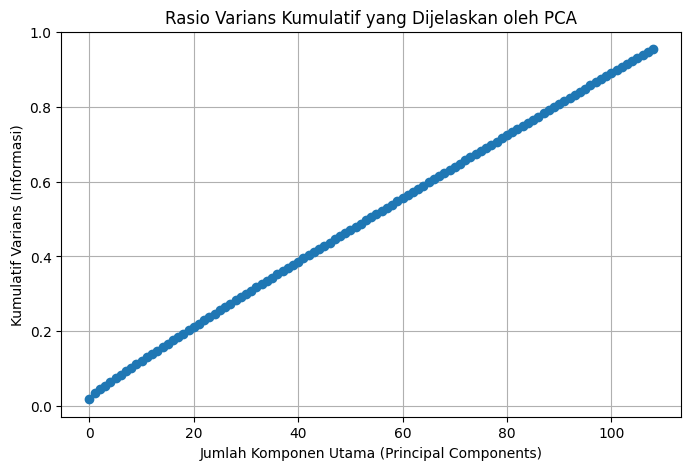

In [5]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"   Dimensi fitur menyusut dari {X_train_scaled.shape[1]} menjadi {X_train_pca.shape[1]} kolom.")

# Visualisasi Kumulatif Varians PCA
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Rasio Varians Kumulatif yang Dijelaskan oleh PCA')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Kumulatif Varians (Informasi)')
plt.grid(True)
plt.show()

In [6]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)

rf_model.fit(X_train_pca, y_train_log)

RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

In [7]:
y_pred_log = rf_model.predict(X_test_pca)

# KEMBALIKAN ke bentuk asli menggunakan np.expm1 (kebalikan dari np.log1p)
y_pred_asli = np.expm1(y_pred_log)
y_test_asli = np.expm1(y_test_log)


          HASIL EVALUASI AKHIR (RUPIAH ASLI)           

Root Mean Squared Error (RMSE)   : Rp 9,475.38
Mean Absolute Error (MAE)        : Rp 4,545.74
Mean Abs. Percentage Error (MAPE): 519051034240984896.00%
Skor R-Squared (R2)              : 91.33%


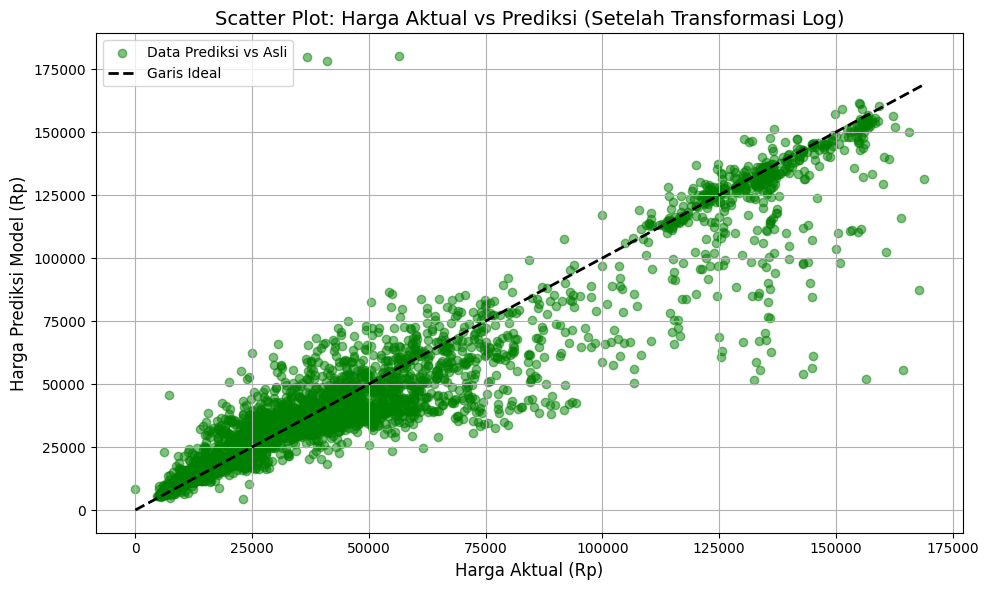

In [8]:
print("\n=======================================================")
print("          HASIL EVALUASI AKHIR (RUPIAH ASLI)           ")
print("=======================================================\n")

mse = mean_squared_error(y_test_asli, y_pred_asli)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_asli, y_pred_asli)
mape = mean_absolute_percentage_error(y_test_asli, y_pred_asli)
r2 = r2_score(y_test_asli, y_pred_asli)

print(f"Root Mean Squared Error (RMSE)   : Rp {rmse:,.2f}")
print(f"Mean Absolute Error (MAE)        : Rp {mae:,.2f}")
print(f"Mean Abs. Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"Skor R-Squared (R2)              : {r2 * 100:.2f}%")

# VISUALISASI PERBANDINGAN HARGA
plt.figure(figsize=(10, 6))
plt.scatter(y_test_asli, y_pred_asli, alpha=0.5, color='green', label='Data Prediksi vs Asli')
plt.plot([y_test_asli.min(), y_test_asli.max()], [y_test_asli.min(), y_test_asli.max()], 'k--', lw=2, label='Garis Ideal')
plt.title('Scatter Plot: Harga Aktual vs Prediksi (Setelah Transformasi Log)', fontsize=14)
plt.xlabel('Harga Aktual (Rp)', fontsize=12)
plt.ylabel('Harga Prediksi Model (Rp)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()